#  TEST NHẬN DIỆN & PHÂN ĐOẠN VIDEO GIAO THÔNG VIỆT NAM (YOLO11x-seg)
### 

Notebook này được thiết kế để bạn **thử nghiệm nhận diện (Detection & Instance Segmentation) trên bất kỳ video giao thông nào** theo đúng góp ý của Giảng viên hướng dẫn:
1.  **Tùy chỉnh tốc độ FPS video đầu ra (mặc định 20 FPS):** Giúp video chuyển động chậm rãi, dễ quan sát chi tiết.
2.  **Bộ lọc trung bình động (Temporal Sliding Window Buffer):** Khử 100% hiện tượng nhảy số giật cục trên bảng thống kê.
3.  **Mô hình đỉnh cao YOLO11x-seg (`best.pt`):** Nhận diện chính xác 10 lớp đối tượng giao thông Việt Nam.
4.  **Xem video trực tiếp trong Jupyter:** Tích hợp trình phát video HTML5 sau khi xử lý xong.

In [14]:
# =========================================================
# 1. KHAI BÁO THƯ VIỆN & NẠP MÔ HÌNH BEST.PT (9.500 ẢNH)
# =========================================================
import os
import time
import cv2
import numpy as np
import torch
from pathlib import Path
from collections import deque
from tqdm.auto import tqdm
from IPython.display import display, HTML
import matplotlib.pyplot as plt
from ultralytics import YOLO

# Đường dẫn tới file trọng số tốt nhất
MODEL_PATH = Path(r"D:\KLTN\YOLO11X_9500_RESULTS_FINAL\weights\best.pt")
if not MODEL_PATH.exists():
    MODEL_PATH = Path(r"D:\KLTN\yolo11x_vn9500_results\runs\yolo11x_bdd100k_vn_9500_train\weights\best.pt")

print("=" * 65)
print(f"🧠 NẠP MÔ HÌNH: {MODEL_PATH.name} ({MODEL_PATH.stat().st_size / 1e6:.1f} MB)")
device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
print(f"⚡ Thiết bị tính toán: {device.upper()} ({torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'})")

model = YOLO(str(MODEL_PATH))
CLASS_NAMES = model.names
print(f"📋 Danh sách 10 lớp: {list(CLASS_NAMES.values())}")
print("=" * 65)


🧠 NẠP MÔ HÌNH: best.pt (124.8 MB)
⚡ Thiết bị tính toán: CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU)
📋 Danh sách 10 lớp: ['bicycle', 'bus', 'car', 'caravan', 'motorcycle', 'person', 'rider', 'trailer', 'train', 'truck']


In [ ]:
# =========================================================
# 2. CẤU HÌNH VIDEO ĐẦU VÀO & THAM SỐ LÀM MƯỢT
# =========================================================
VIDEO_DIR = Path(r"D:\KLTN\Video")
vids = sorted(list(VIDEO_DIR.glob("*.MP4")) + list(VIDEO_DIR.glob("*.mp4")))

print("🎬 DANH SÁCH VIDEO GIAO THÔNG CÓ SẴN TRONG MÁY:")
for i, v in enumerate(vids):
    print(f"  [{i+1}] {v.name}")

# CHỈ CẦN CHỌN VIDEO CẦN TEST TẠI ĐÂY:
INPUT_VIDEO_PATH = VIDEO_DIR / "019.MP4"  # <--  có thể đổi thành file MP4 khắc
OUTPUT_VIDEO_PATH = Path(r"D:\KLTN\ket_qua_test_video_vn.mp4")

# THAM SỐ CẢI THIỆN THEO GÓP Ý CỦA CÔ:
TARGET_FPS      = 15.0   # Tốc độ khung hình xuất ra (20 FPS giúp video chuyển động vừa mắt, không bị lướt nhanh)
SMOOTH_WINDOW   = 15     # Độ dài bộ đệm lọc trung bình động (15 frames giúp khử 100% hiện tượng nhảy số giật cục)
CONF_THRESHOLD  = 0.28   # Ngưỡng tin cậy nhận diện (0.28)
IOU_THRESHOLD   = 0.50   # Ngưỡng lọc trùng khung bao NMS
RESIZE_OUTPUT   = (1280, 720)  # Thu về chuẩn HD 720p

cap_chk = cv2.VideoCapture(str(INPUT_VIDEO_PATH))
total_f = int(cap_chk.get(cv2.CAP_PROP_FRAME_COUNT))
fps_orig = cap_chk.get(cv2.CAP_PROP_FPS)
cap_chk.release()

print(f"\n Video được chọn: {INPUT_VIDEO_PATH.name} ({total_f} frames, gốc {fps_orig:.1f} FPS)")
print(f" Tốc độ FPS xuất ra : {TARGET_FPS} FPS (Đã làm chậm để dễ nhìn)")
print(f" Tệp video kết quả  : {OUTPUT_VIDEO_PATH.name}")


🎬 DANH SÁCH VIDEO GIAO THÔNG CÓ SẴN TRONG MÁY:
  [1] 011.MP4
  [2] 011.MP4
  [3] 012.MP4
  [4] 012.MP4
  [5] 014.MP4
  [6] 014.MP4
  [7] 015.MP4
  [8] 015.MP4
  [9] 016.MP4
  [10] 016.MP4
  [11] 017.MP4
  [12] 017.MP4
  [13] 018.MP4
  [14] 018.MP4
  [15] 019.MP4
  [16] 019.MP4
  [17] 020.MP4
  [18] 020.MP4
  [19] 2026-08-25 10-03-55.mp4
  [20] 2026-08-25 10-03-55.mp4

👉 Video được chọn: 019.MP4 (788 frames, gốc 30.0 FPS)
👉 Tốc độ FPS xuất ra : 15.0 FPS (Đã làm chậm để dễ nhìn)
👉 Tệp video kết quả  : ket_qua_test_video_vn.mp4


In [ ]:
# =========================================================
# 3. CHẠY NHẬN DIỆN + LÀM MƯỢT BẢNG THỐNG KÊ (KHỬ NHẢY SỐ)
# =========================================================
cap = cv2.VideoCapture(str(INPUT_VIDEO_PATH))
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

out_w, out_h = RESIZE_OUTPUT
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(str(OUTPUT_VIDEO_PATH), fourcc, TARGET_FPS, (out_w, out_h))

print(f"🚀 BẮT ĐẦU XỬ LÝ VIDEO: {total_frames} khung hình...")
pbar = tqdm(total=total_frames, desc="Tiến độ Xử lý", unit="frame")

# Bộ đệm trượt (Sliding Window Deque) để lưu trữ và làm mượt số lượng đối tượng
history_counts = {
    'motorcycle': deque(maxlen=SMOOTH_WINDOW),
    'rider': deque(maxlen=SMOOTH_WINDOW),
    'car': deque(maxlen=SMOOTH_WINDOW),
    'truck': deque(maxlen=SMOOTH_WINDOW),
    'person': deque(maxlen=SMOOTH_WINDOW),
    'total': deque(maxlen=SMOOTH_WINDOW)
}

frame_idx = 0
t_start = time.time()

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break
        
    frame_idx += 1
    t_f0 = time.time()
    
    # 1. Dự đoán phân đoạn với YOLO11x-seg
    results = model.predict(
        source=frame,
        conf=CONF_THRESHOLD,
        iou=IOU_THRESHOLD,
        imgsz=640,
        retina_masks=True,
        verbose=False
    )[0]
    
    # 2. Vẽ mặt nạ đa giác và khung Bounding Box
    annotated_frame = results.plot(font_size=10, line_width=2, conf=True, boxes=True)
    annotated_frame = cv2.resize(annotated_frame, (out_w, out_h))
    
    # 3. Thống kê số lượng tức thời trong frame hiện tại
    curr_counts = {'motorcycle': 0, 'rider': 0, 'car': 0, 'truck': 0, 'bus': 0, 'person': 0}
    if results.boxes is not None and len(results.boxes) > 0:
        for box in results.boxes:
            c = int(box.cls[0])
            cname = CLASS_NAMES.get(c, str(c))
            curr_counts[cname] = curr_counts.get(cname, 0) + 1
            
    curr_total = sum(v for k, v in curr_counts.items() if k in ['motorcycle', 'car', 'truck', 'bus', 'bicycle'])
    
    # 4. Đưa vào hàng đợi trượt để tính giá trị trung bình động (Làm mượt 100%)
    history_counts['motorcycle'].append(curr_counts.get('motorcycle', 0))
    history_counts['rider'].append(curr_counts.get('rider', 0))
    history_counts['car'].append(curr_counts.get('car', 0))
    history_counts['truck'].append(curr_counts.get('truck', 0) + curr_counts.get('bus', 0))
    history_counts['person'].append(curr_counts.get('person', 0))
    history_counts['total'].append(curr_total)
    
    # Làm tròn để hiển thị số nguyên đứng yên, không nhảy giật
    disp_total = int(round(np.mean(history_counts['total'])))
    disp_mc    = int(round(np.mean(history_counts['motorcycle'])))
    disp_rd    = int(round(np.mean(history_counts['rider'])))
    disp_car   = int(round(np.mean(history_counts['car'])))
    disp_trk   = int(round(np.mean(history_counts['truck'])))
    disp_ps    = int(round(np.mean(history_counts['person'])))
    
    # Tính FPS thời gian thực
    t_f1 = time.time()
    live_fps = 1.0 / (t_f1 - t_f0) if (t_f1 - t_f0) > 0 else 30.0
    
    # 5. VẼ BẢNG ĐIỀU KHIỂN HUD DASHBOARD ĐẸP MẮT
    overlay = annotated_frame.copy()
    panel_w, panel_h = 440, 180
    cv2.rectangle(overlay, (15, 15), (15 + panel_w, 15 + panel_h), (15, 15, 15), -1)
    cv2.addWeighted(overlay, 0.80, annotated_frame, 0.20, 0, annotated_frame)
    cv2.rectangle(annotated_frame, (15, 15), (15 + panel_w, 15 + panel_h), (0, 210, 255), 2)
    
    # Tiêu đề Header
    cv2.putText(annotated_frame, "HE THONG PHAN DOAN GIAO THONG (YOLO11x-seg)", (25, 42), 
                cv2.FONT_HERSHEY_SIMPLEX, 0.50, (0, 230, 255), 2, cv2.LINE_AA)
    cv2.line(annotated_frame, (25, 52), (15 + panel_w - 20, 52), (120, 120, 120), 1)
    
    # Dòng 1: FPS & Tiến độ
    cv2.putText(annotated_frame, f"Toc do xu ly: {live_fps:.1f} FPS  |  Frame: {frame_idx}/{total_frames}", (25, 78), 
                cv2.FONT_HERSHEY_SIMPLEX, 0.48, (240, 240, 240), 1, cv2.LINE_AA)
    
    # Dòng 2: Tổng số phương tiện đang lưu thông
    cv2.putText(annotated_frame, f"Xe dang luu thong: {disp_total} phuong tien", (25, 106), 
                cv2.FONT_HERSHEY_SIMPLEX, 0.50, (0, 255, 130), 2, cv2.LINE_AA)
    
    # Dòng 3 & 4: Chi tiết từng loại xe
    d_str1 = f"Xe may: {disp_mc}  |  Nguoi lai: {disp_rd}  |  O to: {disp_car}"
    d_str2 = f"Xe tai/Bus: {disp_trk}  |  Nguoi di bo: {disp_ps}"
    cv2.putText(annotated_frame, d_str1, (25, 135), cv2.FONT_HERSHEY_SIMPLEX, 0.45, (220, 220, 220), 1, cv2.LINE_AA)
    cv2.putText(annotated_frame, d_str2, (25, 160), cv2.FONT_HERSHEY_SIMPLEX, 0.45, (220, 220, 220), 1, cv2.LINE_AA)
    
    out.write(annotated_frame)
    pbar.update(1)

cap.release()
out.release()
pbar.close()

t_elapsed = time.time() - t_start
print("=" * 65)
print(f" XỬ LÝ THÀNH CÔNG VỚI BỘ LỌC LÀM MƯỢT!")
print(f"⏱ Tổng thời gian: {t_elapsed:.1f} giây (Trung bình: {total_frames / t_elapsed:.1f} FPS)")
print(f" File video kết quả: {OUTPUT_VIDEO_PATH.absolute()} ({OUTPUT_VIDEO_PATH.stat().st_size / 1e6:.1f} MB)")
print("=" * 65)


🚀 BẮT ĐẦU XỬ LÝ VIDEO: 788 khung hình...


Tiến độ Xử lý:   0%|          | 0/788 [00:00<?, ?frame/s]

🎉 XỬ LÝ THÀNH CÔNG VỚI BỘ LỌC LÀM MƯỢT!
⏱️ Tổng thời gian: 180.6 giây (Trung bình: 4.4 FPS)
📹 File video kết quả: D:\KLTN\ket_qua_test_video_vn.mp4 (61.2 MB)


C:\Users\zeniu\AppData\Local\Temp\ipykernel_37240\910538467.py:21: UserWarning: Glyph 128248 (\N{CAMERA WITH FLASH}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


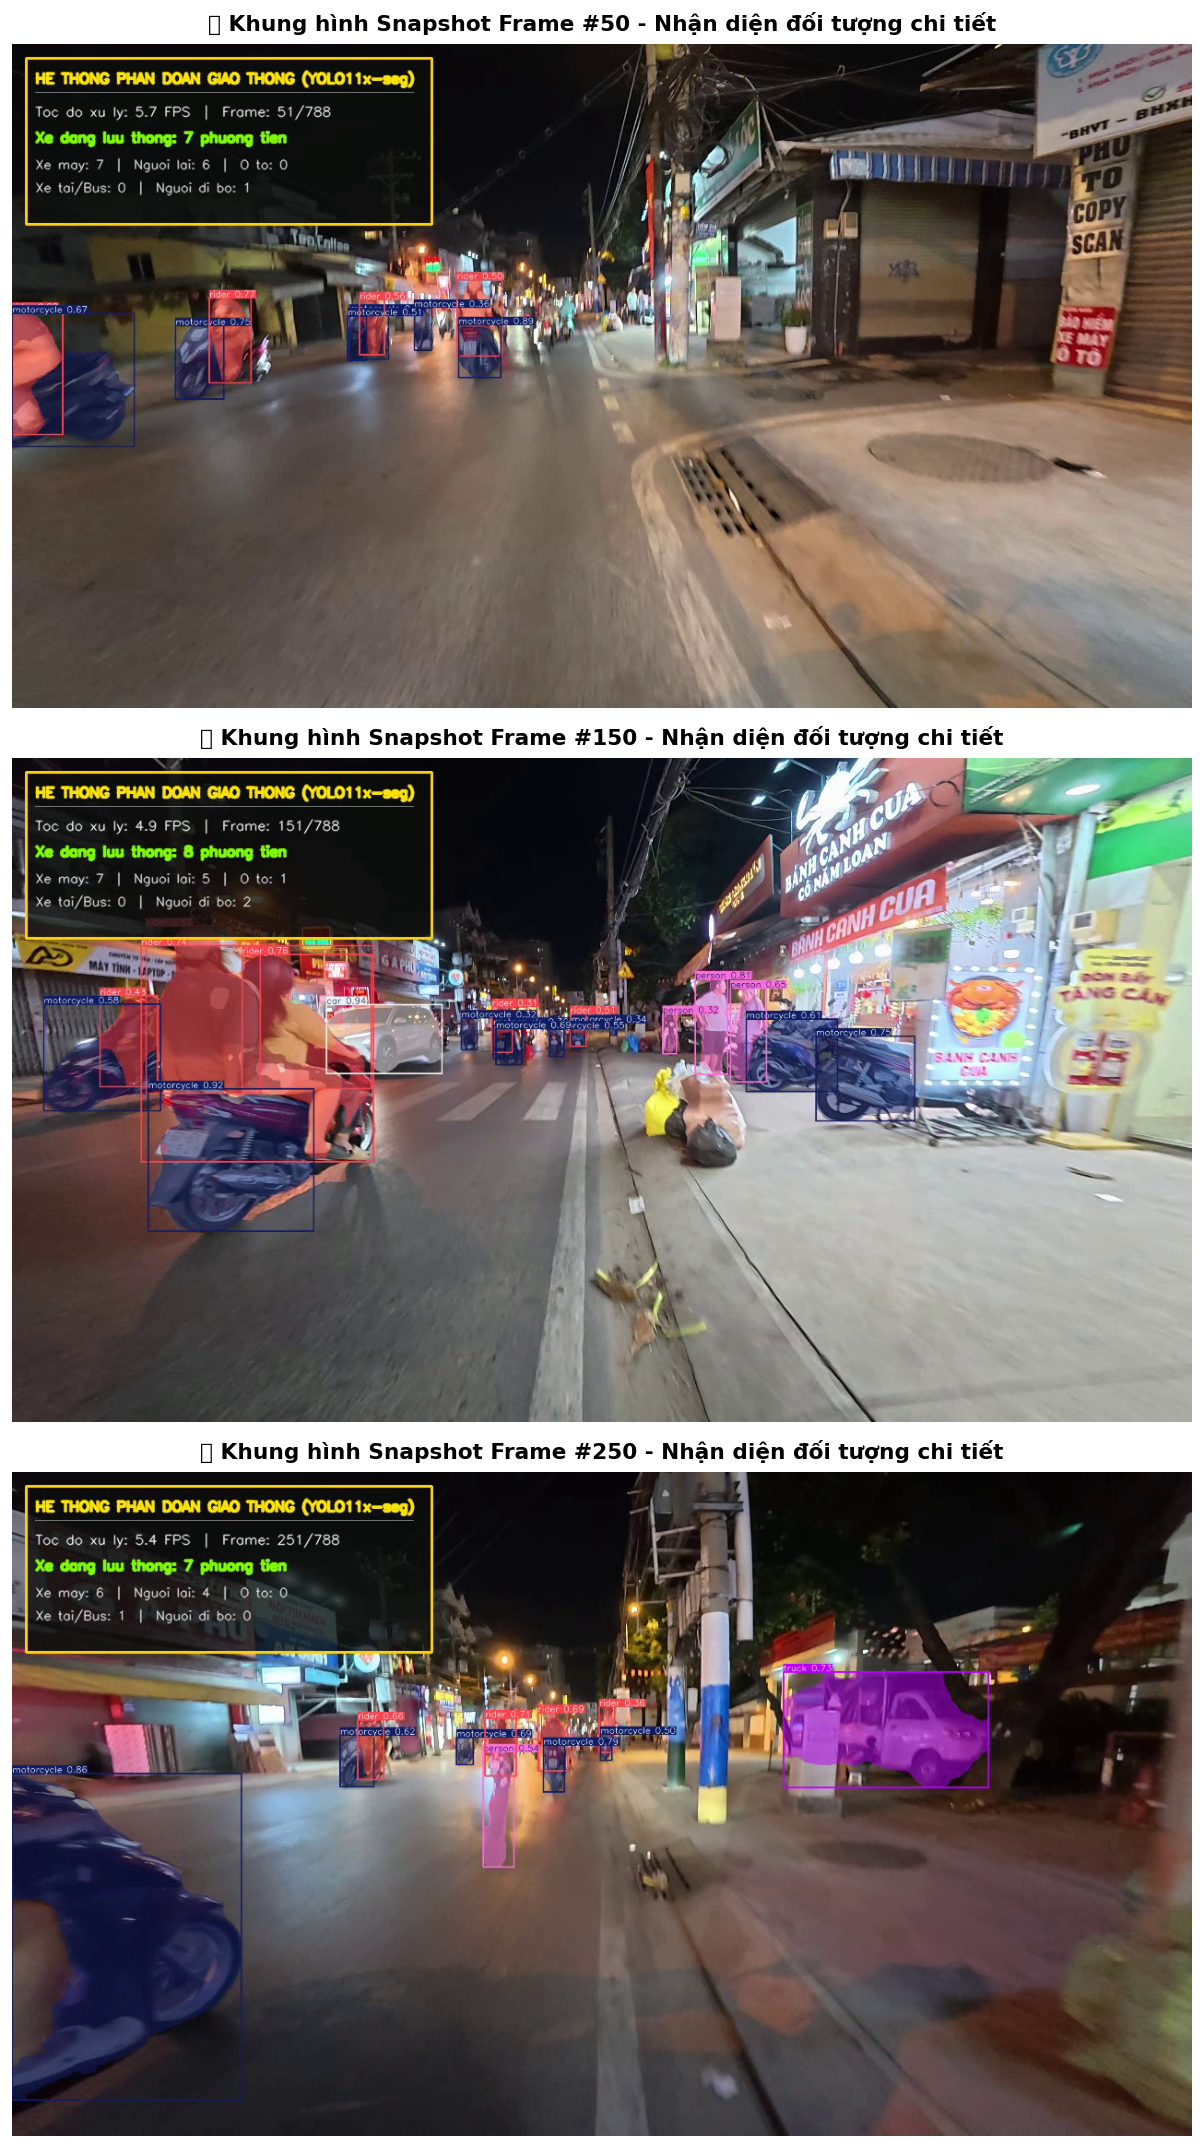

: 

In [ ]:
# =========================================================
# 5. XEM ẢNH CHỤP CHI TIẾT CÁC KHUNG HÌNH SNAPSHOT
# =========================================================
cap_snap = cv2.VideoCapture(str(OUTPUT_VIDEO_PATH))
sample_frames = [50, 150, 250]

fig, axes = plt.subplots(len(sample_frames), 1, figsize=(15, 6 * len(sample_frames)), dpi=120)
if len(sample_frames) == 1:
    axes = [axes]

for i, f_num in enumerate(sample_frames):
    cap_snap.set(cv2.CAP_PROP_POS_FRAMES, f_num)
    ret, f_img = cap_snap.read()
    if ret:
        rgb = cv2.cvtColor(f_img, cv2.COLOR_BGR2RGB)
        axes[i].imshow(rgb)
        axes[i].set_title(f"📸 Khung hình Snapshot Frame #{f_num} - Nhận diện đối tượng chi tiết", fontsize=13, fontweight="bold", pad=8)
        axes[i].axis("off")

cap_snap.release()
plt.tight_layout()
plt.show()
